# Model Exp

## setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## models
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression


## load data

In [6]:
import sys
from pathlib import Path

# Add repo root to sys.path so `src` is importable from the notebooks/ dir
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data.load_data import load_data
from src.data.clean_data import clean_data
from src.data.preprocess import preprocess
from src.data.data_split import data_split
from src.features.features_engineer import features_engineer
from src.services.metrics import evaluate_model

In [7]:
# load data
df = load_data()

# clean data
df_clean = clean_data(df)

# preprocess data
df_prep = preprocess(df_clean)

# feature engineering
df_feat = features_engineer(df_prep)

# data split
X_train, X_test, y_train, y_test = data_split(df_feat)

In [8]:
X_train

,income,name_email_similarity,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,...,source_INTERNET,source_TELEAPP,device_os_linux,device_os_macintosh,device_os_other,device_os_windows,device_os_x11,is_prev_address_months_count_available,is_bank_months_count_available,is_device_distinct_emails_8w_available
0,-0.847913,1.676176,-0.493424,0.523927,-0.308124,3.163725,-0.479509,2.305360,2.012561,2.146742,...,1,0,1,0,0,0,0,0,1,1
1,0.866055,0.407216,0.490298,-1.130107,-0.303067,-0.529776,0.266376,1.020296,0.471870,1.073611,...,1,0,0,0,1,0,0,0,1,1
2,0.866055,1.711248,-0.929187,0.523927,-0.299733,-0.605823,-0.423897,-0.556459,0.271930,1.141841,...,1,0,0,0,0,1,0,1,1,1
3,0.180468,-0.082125,-0.929187,-0.303090,-0.307739,-0.651558,1.501841,2.748661,1.210930,1.112052,...,1,0,1,0,0,0,0,1,1,1
4,1.208848,1.180394,-0.380055,0.523927,2.578556,2.024490,0.839072,0.482157,0.017349,1.072363,...,1,0,0,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794984,1.208848,0.588175,0.581651,-1.130107,-0.271482,-0.465419,1.061862,-0.896780,-0.268538,-1.031734,...,1,0,0,0,0,1,0,0,1,1
794985,0.180468,-0.445456,-0.878058,-0.303090,-0.292991,-0.445305,-0.937721,-0.261183,-0.056915,-0.340305,...,1,0,0,0,0,1,0,1,1,1
794986,0.180468,-0.872444,-0.132583,-1.130107,-0.299730,-0.513689,-0.320806,0.286325,-0.998130,-1.256770,...,1,0,0,0,0,1,0,0,1,1
794987,-1.533499,0.531807,-1.250409,-1.130107,-0.305458,-0.483489,1.237176,-0.929266,-1.119388,-1.190887,...,1,0,0,0,0,1,0,0,0,1


In [9]:
# Identify categorical (string) columns once — used by every model below.
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]
print("categorical:", cat_cols)

# Class imbalance ratio (neg / pos) for scale_pos_weight on the tree models.
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"pos={pos}, neg={neg}, scale_pos_weight={scale_pos_weight:.1f}")

results = {}


categorical: []
pos=8151, neg=786838, scale_pos_weight=96.5


## Models 

In [10]:
from sklearn.metrics import f1_score

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

results = {}
fitted_models = {}   # name -> {"model": ..., "X_test": ...}, used for interpretation later

def best_f1_threshold(y_true, y_score):
    thresholds = np.linspace(0.01, 0.99, 99)
    f1s = [f1_score(y_true, (y_score >= t).astype(int), zero_division=0) for t in thresholds]
    best = int(np.argmax(f1s))
    return thresholds[best], f1s[best]

def score_model(name, train_score, test_score, model=None, X_test_used=None):
    t, _ = best_f1_threshold(y_train, train_score)
    y_pred = (test_score >= t).astype(int)
    results[name] = {**evaluate_model(y_test, y_pred, test_score), "threshold": t}
    if model is not None:
        fitted_models[name] = {"model": model, "X_test": X_test_used}
    return results[name]

In [11]:
def plot_feature_importance(model, feature_names, top_n=20, title=None):
    if hasattr(model, "feature_importances_"):      # LGBM / CatBoost / XGBoost
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):                   # logistic regression
        importances = np.abs(model.coef_).ravel()
    else:
        raise ValueError("model exposes neither feature_importances_ nor coef_")

    order = np.argsort(importances)[::-1][:top_n]
    names = np.array(feature_names)[order]
    vals = importances[order]

    plt.figure(figsize=(8, max(4, 0.35 * len(order))))
    plt.barh(names[::-1], vals[::-1])               # largest at top
    plt.xlabel("importance")
    plt.title(title or type(model).__name__)
    plt.tight_layout()
    plt.show()


### Baseline model(logistic regression)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

logreg = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, n_jobs=-1)),
])
logreg.fit(X_train, y_train)

score_model("logistic_regression",
            logreg.predict_proba(X_train)[:, 1],
            logreg.predict_proba(X_test)[:, 1],
            model=logreg, X_test_used=X_test)

/Users/thanakritp/Documents/Thanakrit_workspace/Class/practical-ml-final-project/Fraud-Detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'precision': 0.23841059602649006,
 'recall': 0.2126476719944406,
 'f1_score': 0.22479338842975208,
 'pr_auc': 0.16003868604391647,
 'threshold': np.float64(0.09999999999999999)}

In [9]:
print("train pr_auc:", average_precision_score(y_train, logreg.predict_proba(X_train)[:, 1]))
print("test  pr_auc:", average_precision_score(y_test,  logreg.predict_proba(X_test)[:, 1]))

train pr_auc: 0.12630698748425173
test  pr_auc: 0.16003868604391647


## lightgbm without tuning

I add early stopping bc first try it's overfitting

In [10]:
X_train_lgb, X_test_lgb = X_train.copy(), X_test.copy()
for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    X_test_lgb[c] = X_test_lgb[c].astype("category")

lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=32,
                      n_jobs=-1, random_state=42)
lgbm.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],          
    eval_metric="average_precision",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
)

score_model("lightgbm",
            lgbm.predict_proba(X_train_lgb)[:, 1],
            lgbm.predict_proba(X_test_lgb)[:, 1],
            model=lgbm, X_test_used=X_test_lgb)

[LightGBM] [Info] Number of positive: 8151, number of negative: 786838
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2921
[LightGBM] [Info] Number of data points in the train set: 794989, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010253 -> initscore=-4.569882
[LightGBM] [Info] Start training from score -4.569882
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[129]	valid_0's average_precision: 0.186661	valid_0's binary_logloss: 0.0550009


{'precision': 0.23081009296148738,
 'recall': 0.3019457956914524,
 'f1_score': 0.26162878217672736,
 'pr_auc': 0.18666114212301957,
 'threshold': np.float64(0.11)}

In [11]:
print("train pr_auc:", average_precision_score(y_train, lgbm.predict_proba(X_train_lgb)[:, 1]))
print("test  pr_auc:", average_precision_score(y_test,  lgbm.predict_proba(X_test_lgb)[:, 1]))

train pr_auc: 0.22181747380189404
test  pr_auc: 0.18666114212301957


## Catboost without tuning

In [12]:
catboost = CatBoostClassifier(iterations=500, learning_rate=0.02, depth=8,
                              random_seed=42, verbose=0)
catboost.fit(X_train, y_train, cat_features=cat_cols, early_stopping_rounds=50, eval_set=(X_test, y_test))

score_model("catboost",
            catboost.predict_proba(X_train)[:, 1],
            catboost.predict_proba(X_test)[:, 1],
            model=catboost, X_test_used=X_test)

{'precision': 0.2661570535093815,
 'recall': 0.2661570535093815,
 'f1_score': 0.2661570535093815,
 'pr_auc': 0.1912542078893003,
 'threshold': np.float64(0.12)}

In [13]:
print("train pr_auc:", average_precision_score(y_train, catboost.predict_proba(X_train)[:, 1]))
print("test  pr_auc:", average_precision_score(y_test,  catboost.predict_proba(X_test)[:, 1]))

train pr_auc: 0.22933239951540346
test  pr_auc: 0.1912542078893003


## Xgboost without tuning


In [14]:
from xgboost import XGBClassifier

X_train_xgb, X_test_xgb = X_train.copy(), X_test.copy()
for c in cat_cols:
    X_train_xgb[c] = X_train_xgb[c].astype("category")
    X_test_xgb[c] = X_test_xgb[c].astype("category")

xgb_model = XGBClassifier(
    n_estimators=500, learning_rate=0.02, max_depth=6,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist", enable_categorical=True,   
    eval_metric="aucpr",                            
    early_stopping_rounds=50,                       
    n_jobs=-1, random_state=42,
)
xgb_model.fit(X_train_xgb, y_train, eval_set=[(X_test_xgb, y_test)], verbose=False)

score_model("xgboost",
            xgb_model.predict_proba(X_train_xgb)[:, 1],
            xgb_model.predict_proba(X_test_xgb)[:, 1],
            model=xgb_model, X_test_used=X_test_xgb)

{'precision': 0.2388772767990445,
 'recall': 0.27797081306462823,
 'f1_score': 0.25694555965954713,
 'pr_auc': 0.1873230462628581,
 'threshold': np.float64(0.9)}

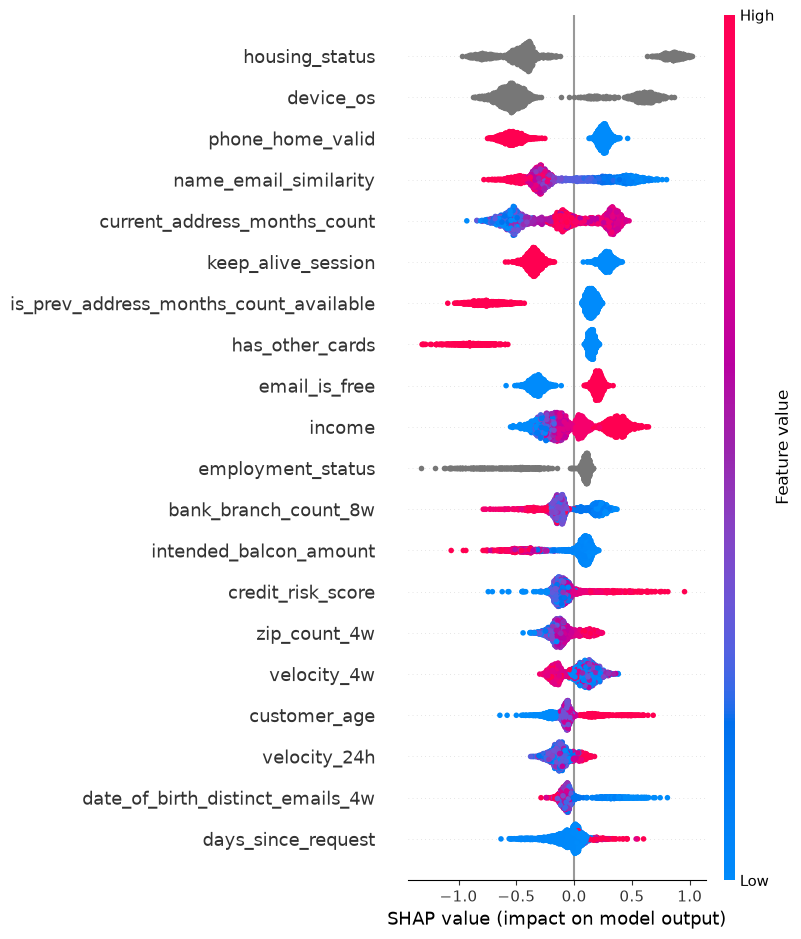

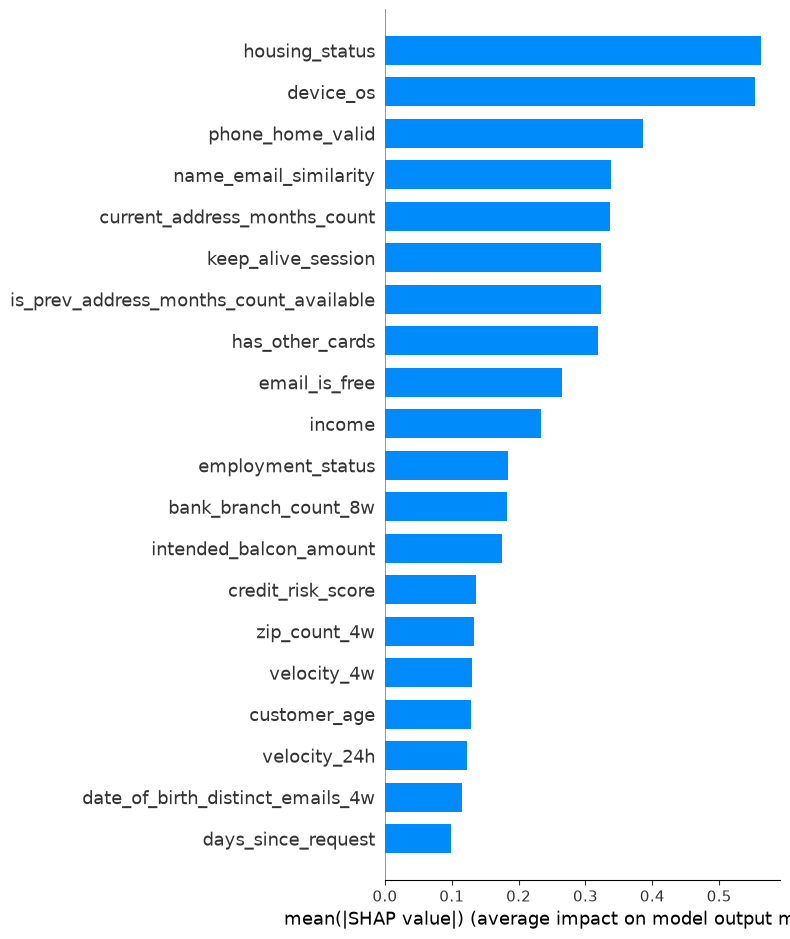

In [15]:
import shap

explainer = shap.TreeExplainer(xgb_model)          # or catboost / xgb_model

X_sample = X_test_lgb.sample(2000, random_state=42)   # use the category-dtype frame
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)       # beeswarm: importance + direction
shap.summary_plot(shap_values, X_sample, plot_type="bar")   # global ranking


/Users/thanakritp/Documents/Thanakrit_workspace/Class/practical-ml-final-project/Fraud-Detection/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


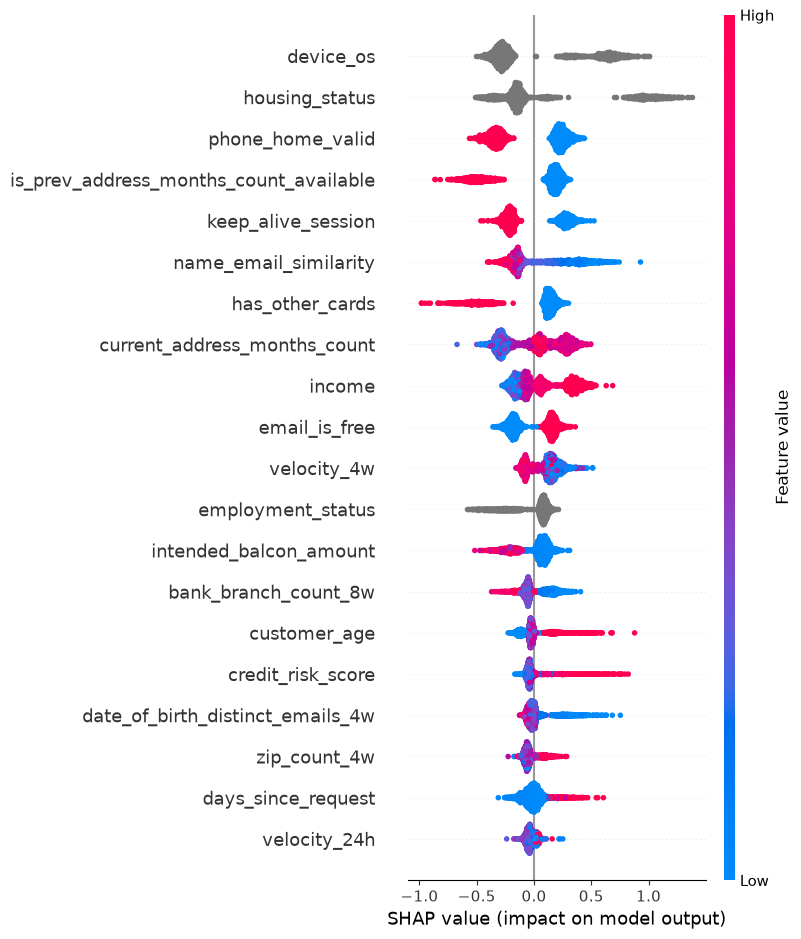

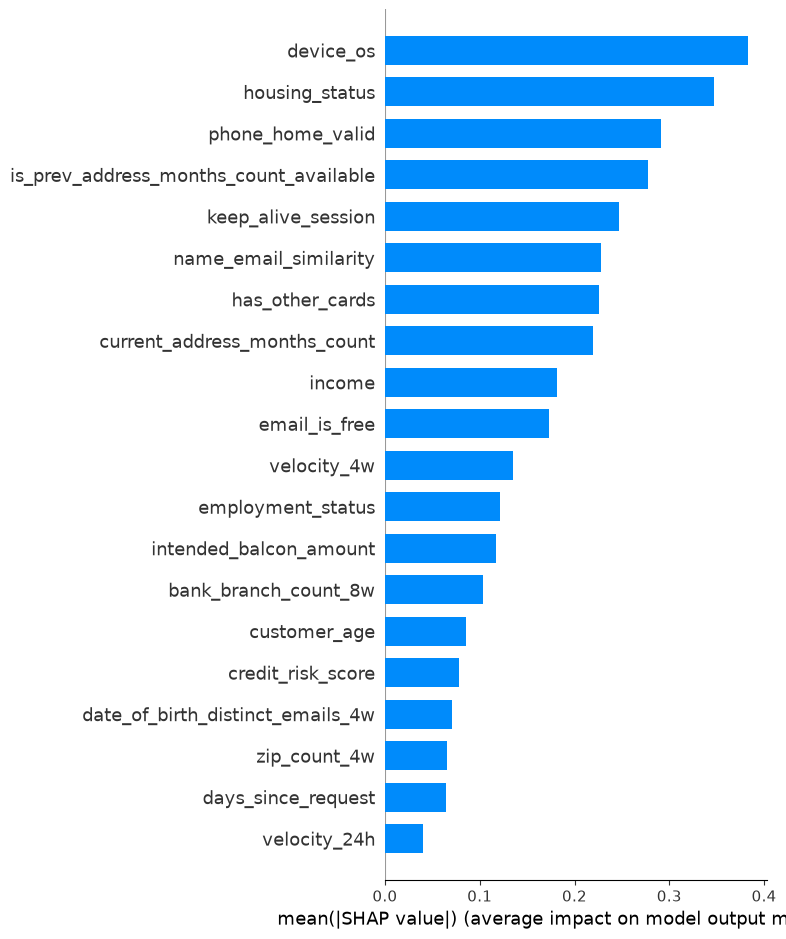

In [16]:
explainer = shap.TreeExplainer(lgbm)          # or catboost / xgb_model

X_sample = X_test_lgb.sample(2000, random_state=42)   # use the category-dtype frame
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)       # beeswarm: importance + direction
shap.summary_plot(shap_values, X_sample, plot_type="bar")   # global ranking


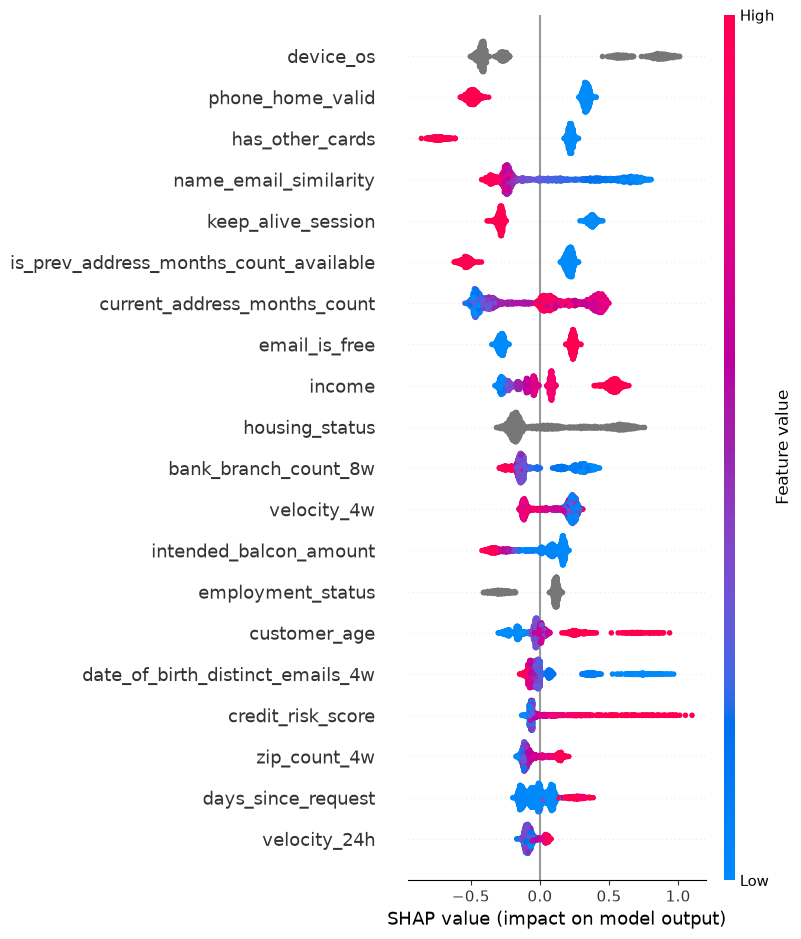

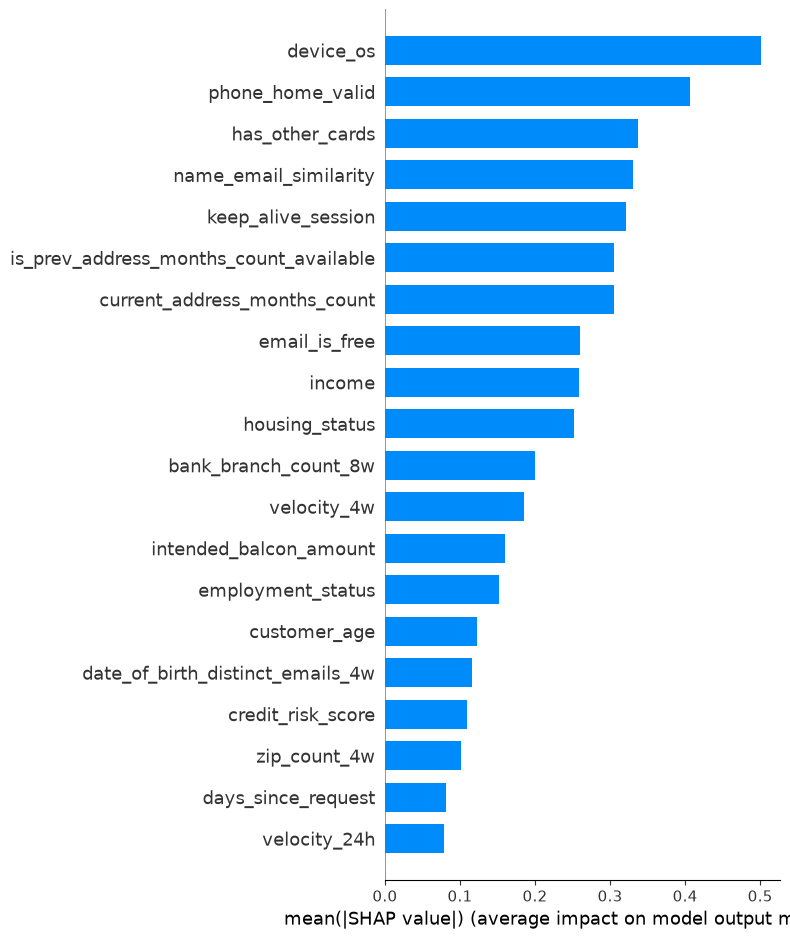

In [ ]:
explainer = shap.TreeExplainer(catboost)          

X_sample = X_test_lgb.sample(2000, random_state=42) 
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)      
shap.summary_plot(shap_values, X_sample, plot_type="bar")   


## Feature selection + tuning (no SMOTE)

CatBoost-only experiments (best model from above). All fit on months 0–4, early-stop / tune on month 5, evaluate on test:
1. **top-10 features** — top-10 numerical by mutual information + the categoricals, default params
2. **tuning** — Optuna on all features
3. **combine** — top-10 features + Optuna tuning

In [22]:
from sklearn.feature_selection import mutual_info_classif

month_of = df_feat.loc[X_train.index, "month"]
fit_idx = month_of[month_of <= 4].index
val_idx = month_of[month_of == 5].index

X_fit, y_fit = X_train.loc[fit_idx], y_train.loc[fit_idx]
X_val, y_val = X_train.loc[val_idx], y_train.loc[val_idx]
print("fit:", X_fit.shape, "| val:", X_val.shape)

samp = X_train.sample(50_000, random_state=42)
mi = mutual_info_classif(samp[num_cols], y_train.loc[samp.index], random_state=42)
mi_scores = pd.Series(mi, index=num_cols).sort_values(ascending=False)

top10_num = mi_scores.head(15).index.tolist()
selected_features = top10_num + cat_cols          
all_features = num_cols + cat_cols                

print("\ntop-15 numerical:\n", mi_scores.head(15))
print("\nselected_features:", selected_features)

fit: (675666, 29) | val: (119323, 29)

top-15 numerical:
 is_bank_months_count_available            0.010406
keep_alive_session                        0.009996
is_device_distinct_emails_8w_available    0.009494
phone_mobile_valid                        0.009199
email_is_free                             0.009059
proposed_credit_limit                     0.006345
phone_home_valid                          0.005678
is_prev_address_months_count_available    0.004264
customer_age                              0.004207
income                                    0.003422
date_of_birth_distinct_emails_4w          0.002003
credit_risk_score                         0.001935
has_other_cards                           0.001886
current_address_months_count              0.001883
name_email_similarity                     0.001398
dtype: float64

selected_features: ['is_bank_months_count_available', 'keep_alive_session', 'is_device_distinct_emails_8w_available', 'phone_mobile_valid', 'email_is_free', 'pro

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def run_catboost(name, params, features):
    cats = [c for c in cat_cols if c in features]
    cb = CatBoostClassifier(**params, random_seed=42, verbose=0)
    cb.fit(X_fit[features], y_fit, cat_features=cats,
           eval_set=(X_val[features], y_val), early_stopping_rounds=50)
    score_model(name,
                cb.predict_proba(X_train[features])[:, 1],
                cb.predict_proba(X_test[features])[:, 1],
                model=cb, X_test_used=X_test[features])
    return cb

def make_objective(features):
    cats = [c for c in cat_cols if c in features]
    def objective(trial):
        params = dict(
            iterations=1000,
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            depth=trial.suggest_int("depth", 4, 10),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
            random_strength=trial.suggest_float("random_strength", 0.0, 5.0),
        )
        cb = CatBoostClassifier(**params, random_seed=42, verbose=0)
        cb.fit(X_fit[features], y_fit, cat_features=cats,
               eval_set=(X_val[features], y_val), early_stopping_rounds=50)
        return average_precision_score(y_val, cb.predict_proba(X_val[features])[:, 1])
    return objective

In [24]:
default_params = dict(iterations=1000, learning_rate=0.02, depth=8)
cb_top10 = run_catboost("catboost_top10", default_params, selected_features)
results["catboost_top10"]

{'precision': 0.25059910989387196,
 'recall': 0.2543432939541348,
 'f1_score': 0.25245732022762546,
 'pr_auc': 0.17813051808675245,
 'threshold': np.float64(0.11)}

In [36]:
study_all = optuna.create_study(direction="maximize")
study_all.optimize(make_objective(all_features), n_trials=30, show_progress_bar=True)
print("best val pr_auc:", round(study_all.best_value, 4))
print("best params:", study_all.best_params)

cb_tuned = run_catboost("catboost_tuned",
                        {**study_all.best_params, "iterations": 1000},
                        all_features)
results["catboost_tuned"]

Best trial: 21. Best value: 0.182016: 100%|██████████| 30/30 [41:18<00:00, 82.61s/it]


best val pr_auc: 0.182
best params: {'learning_rate': 0.08753065673889224, 'depth': 4, 'l2_leaf_reg': 1.795178350822508, 'random_strength': 1.0720659686193552}


{'precision': 0.2508601814200813,
 'recall': 0.2786657400972898,
 'f1_score': 0.2640329218106996,
 'pr_auc': 0.1911442320076527,
 'threshold': np.float64(0.11)}

In [38]:
results["catboost_tuned"]

{'precision': 0.2508601814200813,
 'recall': 0.2786657400972898,
 'f1_score': 0.2640329218106996,
 'pr_auc': 0.1911442320076527,
 'threshold': np.float64(0.11)}

## Undersampling (RandomUnderSampler)

Balance the classes by dropping majority rows instead of synthesizing minority ones (SMOTE's counterpart). Applied to **train only**; test is untouched. Threshold is still swept on the real (imbalanced) train distribution.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)

print("before:", y_train.value_counts().to_dict())
print("after :", y_train_us.value_counts().to_dict())

before: {0: 786838, 1: 8151}
after : {0: 8151, 1: 8151}


In [26]:
logreg = Pipeline(steps=[
    ("prep", ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])),
    ("clf", LogisticRegression(max_iter=1000)),
])
logreg.fit(X_train_us, y_train_us)

score_model("logistic_regression_under",
            logreg.predict_proba(X_train)[:, 1],
            logreg.predict_proba(X_test)[:, 1],
            model=logreg, X_test_used=X_test)

{'precision': 0.23094425483503983,
 'recall': 0.21160528144544824,
 'f1_score': 0.22085222121486853,
 'pr_auc': 0.15518879007154493,
 'threshold': np.float64(0.91)}

In [27]:
X_us_lgb = to_cat(X_train_us)
X_train_lgb, X_test_lgb = to_cat(X_train), to_cat(X_test)

lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=32,
                      n_jobs=-1, random_state=42)
lgbm.fit(
    X_us_lgb, y_train_us,
    eval_set=[(X_test_lgb, y_test)],
    eval_metric="average_precision",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)],
)

score_model("lightgbm_under",
            lgbm.predict_proba(X_train_lgb)[:, 1],
            lgbm.predict_proba(X_test_lgb)[:, 1],
            model=lgbm, X_test_used=X_test_lgb)

[LightGBM] [Info] Number of positive: 8151, number of negative: 8151
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2911
[LightGBM] [Info] Number of data points in the train set: 16302, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[82]	valid_0's average_precision: 0.175274	valid_0's binary_logloss: 0.428468


{'precision': 0.23187537447573398,
 'recall': 0.2689367616400278,
 'f1_score': 0.24903474903474904,
 'pr_auc': 0.17527387273419398,
 'threshold': np.float64(0.88)}

In [28]:
catboost = CatBoostClassifier(iterations=500, learning_rate=0.02, depth=8,
                              random_seed=42, verbose=0)
catboost.fit(X_train_us, y_train_us, cat_features=cat_cols,
             early_stopping_rounds=50, eval_set=(X_test, y_test))

score_model("catboost_under",
            catboost.predict_proba(X_train)[:, 1],
            catboost.predict_proba(X_test)[:, 1],
            model=catboost, X_test_used=X_test)

{'precision': 0.24469067405355494,
 'recall': 0.27623349548297427,
 'f1_score': 0.2595070997225396,
 'pr_auc': 0.1891782692877535,
 'threshold': np.float64(0.9)}

In [29]:
X_us_xgb = to_cat(X_train_us)
X_train_xgb, X_test_xgb = to_cat(X_train), to_cat(X_test)

xgb_model = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    tree_method="hist", enable_categorical=True,
    eval_metric="aucpr", early_stopping_rounds=50,
    n_jobs=-1, random_state=42,
)
xgb_model.fit(X_us_xgb, y_train_us, eval_set=[(X_test_xgb, y_test)], verbose=False)

score_model("xgboost_under",
            xgb_model.predict_proba(X_train_xgb)[:, 1],
            xgb_model.predict_proba(X_test_xgb)[:, 1],
            model=xgb_model, X_test_used=X_test_xgb)

{'precision': 0.208838043965904,
 'recall': 0.3234885337039611,
 'f1_score': 0.2538167938931298,
 'pr_auc': 0.17970575500445568,
 'threshold': np.float64(0.91)}

## Tuned tree models on SMOTE & Undersampling

Resampling changes the data, so hyperparameters are **re-searched with Optuna** for each
(model × resampling) combo — XGBoost, LightGBM, CatBoost on SMOTE and Undersampling (6 studies,
search spaces mirror `config.json`). Each model trains on the **resampled months 0–4**,
early-stops / tunes on the **real month-5** validation, and is scored on the untouched test set
(metrics now include `recall@5fpr` from `src/services/metrics.py`). SMOTE data is ~1.3M rows, so it
uses fewer trials (15) than undersampling (30). **Heads-up: the SMOTE studies are slow** (the
earlier 30-trial CatBoost run took ~40 min; SMOTE data is larger).

In [ ]:
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler
import optuna
from xgboost import XGBClassifier


_month = df_feat.loc[X_train.index, "month"]
X_fit, y_fit = X_train.loc[_month[_month <= 4].index], y_train.loc[_month[_month <= 4].index]
X_val, y_val = X_train.loc[_month[_month == 5].index], y_train.loc[_month[_month == 5].index]

cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

def resample_fit(kind):

    if kind == "smote":
        rs = SMOTENC(categorical_features=cat_idx, random_state=42) if cat_idx else SMOTE(random_state=42)
    else:
        rs = RandomUnderSampler(random_state=42)
    return rs.fit_resample(X_fit, y_fit)

def xgb_space(trial):
    return dict(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    )

def lgbm_space(trial):
    return dict(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 16, 128),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    )

def cat_space(trial):
    return dict(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        depth=trial.suggest_int("depth", 4, 10),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        random_strength=trial.suggest_float("random_strength", 0.0, 5.0),
    )


def fit_xgb(params, Xtr, ytr):
    m = XGBClassifier(**params, tree_method="hist", enable_categorical=True,
                      eval_metric="aucpr", early_stopping_rounds=50, n_jobs=-1, random_state=42)
    m.fit(to_cat(Xtr), ytr, eval_set=[(to_cat(X_val), y_val)], verbose=False)
    return m, to_cat

def fit_lgbm(params, Xtr, ytr):
    m = LGBMClassifier(**params, n_jobs=-1, random_state=42)
    m.fit(to_cat(Xtr), ytr, eval_set=[(to_cat(X_val), y_val)],
          eval_metric="average_precision", categorical_feature=cat_cols,
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    return m, to_cat

def fit_cat(params, Xtr, ytr):
    m = CatBoostClassifier(**params, random_seed=42, verbose=0)
    m.fit(Xtr, ytr, cat_features=cat_cols, eval_set=(X_val, y_val), early_stopping_rounds=50)
    return m, (lambda d: d)

MODELS = {
    "xgboost":  (fit_xgb,  xgb_space,  {"n_estimators": 2000}),
    "lightgbm": (fit_lgbm, lgbm_space, {"n_estimators": 2000, "subsample_freq": 1}),
    "catboost": (fit_cat,  cat_space,  {"iterations": 2000}),
}

In [ ]:
N_TRIALS = {"smote": 15, "under": 30}  

def resample_all(kind):
    """Resample the FULL train (months 0-5) for the final refit."""
    if kind == "smote":
        rs = SMOTENC(categorical_features=cat_idx, random_state=42) if cat_idx else SMOTE(random_state=42)
    else:
        rs = RandomUnderSampler(random_state=42)
    return rs.fit_resample(X_train, y_train)

def n_trees(m):
    if isinstance(m, XGBClassifier):  return int(m.best_iteration) + 1
    if isinstance(m, LGBMClassifier): return int(m.best_iteration_)
    return int(m.get_best_iteration()) + 1          # CatBoost

def refit_full(key, params, n_iter, Xr, yr):
    """Refit on the full resampled train (0-5) with a fixed iteration count (no early stopping)."""
    if key == "xgboost":
        m = XGBClassifier(**params, n_estimators=n_iter, tree_method="hist", enable_categorical=True,
                          eval_metric="aucpr", n_jobs=-1, random_state=42)
        m.fit(to_cat(Xr), yr, verbose=False); return m, to_cat
    if key == "lightgbm":
        m = LGBMClassifier(**params, n_estimators=n_iter, subsample_freq=1, n_jobs=-1, random_state=42)
        m.fit(to_cat(Xr), yr, categorical_feature=cat_cols); return m, to_cat
    m = CatBoostClassifier(**params, iterations=n_iter, random_seed=42, verbose=0)
    m.fit(Xr, yr, cat_features=cat_cols); return m, (lambda d: d)

for kind in ["smote", "under"]:
    Xr_fit, yr_fit = resample_fit(kind)     # months 0-4 resampled  -> tuning + best_iteration
    Xr_all, yr_all = resample_all(kind)     # months 0-5 resampled  -> final refit
    print(f"\n=== {kind}: fit(0-4)={dict(pd.Series(yr_fit).value_counts())} "
          f"all(0-5)={dict(pd.Series(yr_all).value_counts())} ===")
    for key, (fit_fn, space, fixed) in MODELS.items():
        def objective(trial, fit_fn=fit_fn, space=space, fixed=fixed):
            m, prep = fit_fn({**space(trial), **fixed}, Xr_fit, yr_fit)
            return average_precision_score(y_val, m.predict_proba(prep(X_val))[:, 1])
        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=N_TRIALS[kind], show_progress_bar=True)

        # recover best_iteration on the 0-4 / month-5 fold, then refit on the full resampled 0-5
        probe, _ = fit_fn({**study.best_params, **fixed}, Xr_fit, yr_fit)
        best_iter = n_trees(probe)
        m, prep = refit_full(key, study.best_params, best_iter, Xr_all, yr_all)

        name = f"{key}_{kind}_tuned"
        score_model(name,
                    m.predict_proba(prep(X_train))[:, 1],
                    m.predict_proba(prep(X_test))[:, 1],
                    model=m, X_test_used=prep(X_test))
        print(f"{name}: best_val_pr_auc={study.best_value:.4f} best_iter={best_iter} | "
              f"test={ {k: round(v, 4) for k, v in results[name].items()} }")
        print(f"  best_params = {study.best_params}")

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

UNDER_BEST = {
    "xgboost":  {"learning_rate": 0.011197688724993732, "max_depth": 3, "min_child_weight": 10,
                 "subsample": 0.6097508738062233, "colsample_bytree": 0.8657630801040974,
                 "gamma": 0.1735483323349145, "reg_lambda": 0.1609840456892666,
                 "reg_alpha": 0.0029444185749029966},
    "lightgbm": {"learning_rate": 0.024608280355412713, "num_leaves": 115, "max_depth": 4,
                 "min_child_samples": 130, "subsample": 0.5108540511713935,
                 "colsample_bytree": 0.6511590561984508, "reg_lambda": 0.291093035088335,
                 "reg_alpha": 0.031801385805089115},
    "catboost": {"learning_rate": 0.01795343287611892, "depth": 5,
                 "l2_leaf_reg": 3.6237692198094633, "random_strength": 0.715177711965264},
}

def _n_trees(m):
    if isinstance(m, XGBClassifier):  return int(m.best_iteration) + 1
    if isinstance(m, LGBMClassifier): return int(m.best_iteration_)
    return int(m.get_best_iteration()) + 1

def _refit_full(key, params, n_iter, Xr, yr):
    if key == "xgboost":
        m = XGBClassifier(**params, n_estimators=n_iter, tree_method="hist", enable_categorical=True,
                          eval_metric="aucpr", n_jobs=-1, random_state=42)
        m.fit(to_cat(Xr), yr, verbose=False); return m, to_cat
    if key == "lightgbm":
        m = LGBMClassifier(**params, n_estimators=n_iter, subsample_freq=1, n_jobs=-1, random_state=42)
        m.fit(to_cat(Xr), yr, categorical_feature=cat_cols); return m, to_cat
    m = CatBoostClassifier(**params, iterations=n_iter, random_seed=42, verbose=0)
    m.fit(Xr, yr, cat_features=cat_cols); return m, (lambda d: d)

# undersample 0-4 (to recover best_iteration) and 0-5 (for the final fit)
Xf_us, yf_us = RandomUnderSampler(random_state=42).fit_resample(X_fit, y_fit)
Xa_us, ya_us = RandomUnderSampler(random_state=42).fit_resample(X_train, y_train)

for key, (fit_fn, space, fixed) in MODELS.items():
    probe, _ = fit_fn({**UNDER_BEST[key], **fixed}, Xf_us, yf_us)   # early-stop on month 5
    best_iter = _n_trees(probe)
    m, prep = _refit_full(key, UNDER_BEST[key], best_iter, Xa_us, ya_us)
    name = f"{key}_under_tuned"
    score_model(name,
                m.predict_proba(prep(X_train))[:, 1],
                m.predict_proba(prep(X_test))[:, 1],
                model=m, X_test_used=prep(X_test))
    print(f"{name}: "
          f"test={ {k: round(v, 4) for k, v in results[name].items()} }")

xgboost_under_tuned: best_iter=1372 | test={'precision': 0.218, 'recall': 0.3402, 'f1_score': 0.2657, 'pr_auc': 0.1935, 'recall@5fpr': np.float64(0.5476), 'threshold': np.float64(0.9)}
[LightGBM] [Info] Number of positive: 6740, number of negative: 6740
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2930
[LightGBM] [Info] Number of data points in the train set: 13480, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

In [ ]:
# Logistic Regression, tuned with Optuna on SMOTE and Undersampling
# tuned on months 0-4 (val = month 5); final model refit on the full resampled train (0-5)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

LOGREG_TRIALS = {"smote": 15, "under": 30}

def logreg_space(trial):
    return dict(
        C=trial.suggest_float("C", 1e-3, 10.0, log=True),
        class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
    )

def fit_logreg(params, Xtr, ytr):
    m = Pipeline([
        ("prep", ColumnTransformer([
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ])),
        ("clf", LogisticRegression(max_iter=1000, **params)),
    ])
    m.fit(Xtr, ytr)
    return m

for kind in ["smote", "under"]:
    Xr_fit, yr_fit = resample_fit(kind)     # 0-4 for tuning
    Xr_all, yr_all = resample_all(kind)     # 0-5 for the final refit

    def objective(trial):
        m = fit_logreg(logreg_space(trial), Xr_fit, yr_fit)
        return average_precision_score(y_val, m.predict_proba(X_val)[:, 1])

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=LOGREG_TRIALS[kind], show_progress_bar=True)

    m = fit_logreg(study.best_params, Xr_all, yr_all)   # refit on full resampled 0-5
    name = f"logistic_regression_{kind}_tuned"
    score_model(name,
                m.predict_proba(X_train)[:, 1],
                m.predict_proba(X_test)[:, 1],
                model=m, X_test_used=X_test)
    print(f"{name}: best_val_pr_auc={study.best_value:.4f} | "
          f"test={ {k: round(v, 4) for k, v in results[name].items()} }")
    print(f"  best_params = {study.best_params}")

In [35]:
results_df = pd.DataFrame(results).T.sort_values("f1_score", ascending=False)
results_df

,precision,recall,f1_score,pr_auc,recall@5fpr,threshold
catboost_final,0.238368,0.318624,0.272714,0.194818,0.544128,0.11
catboost_under_tuned,0.238221,0.312717,0.270433,0.195790,0.551772,0.91
xgboost_final,0.233005,0.320361,0.269788,0.196475,0.547603,0.11
xgboost_under_tuned,0.218040,0.340167,0.265744,0.193501,0.547603,0.90
lightgbm_under_tuned,0.218080,0.339472,0.265561,0.192683,0.544475,0.91
lightgbm_final,0.226033,0.279361,0.249883,0.179140,0.519110,0.12
catboost_smote_tuned,0.250557,0.234538,0.242283,0.175171,0.518763,0.16
lightgbm_smote_tuned,0.253273,0.215080,0.232619,0.176468,0.523628,0.18
xgboost_smote_tuned,0.248194,0.202919,0.223284,0.158926,0.508339,0.24
logistic_regression_under_tuned,0.235119,0.192147,0.211472,0.151058,0.487144,0.89


## Model Interpretation

Pick the best model from `results` (by PR-AUC) and explain it: built-in feature importance +
SHAP (beeswarm shows importance *and* direction; bar shows the global ranking).

best model by recall@5fpr: catboost_under_tuned
{'precision': 0.2382212811011117, 'recall': 0.3127171646977067, 'f1_score': 0.2704326923076923, 'pr_auc': 0.1957899118855395, 'recall@5fpr': np.float64(0.551772063933287), 'threshold': np.float64(0.91)}


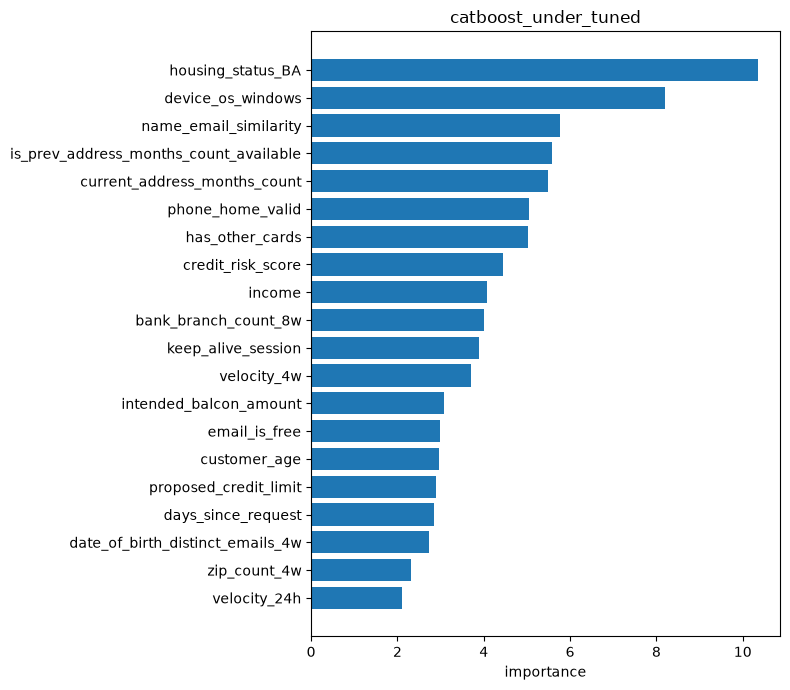

In [36]:
from sklearn.pipeline import Pipeline

METRIC = "recall@5fpr"  
best_name = max(results, key=lambda k: results[k][METRIC])
model = fitted_models[best_name]["model"]
X_te = fitted_models[best_name]["X_test"]
print(f"best model by {METRIC}: {best_name}")
print(results[best_name])

if isinstance(model, Pipeline):
    clf = model.named_steps["clf"]
    names = model.named_steps["prep"].get_feature_names_out()
    plot_feature_importance(clf, names, title=best_name)
else:
    plot_feature_importance(model, X_te.columns, title=best_name)

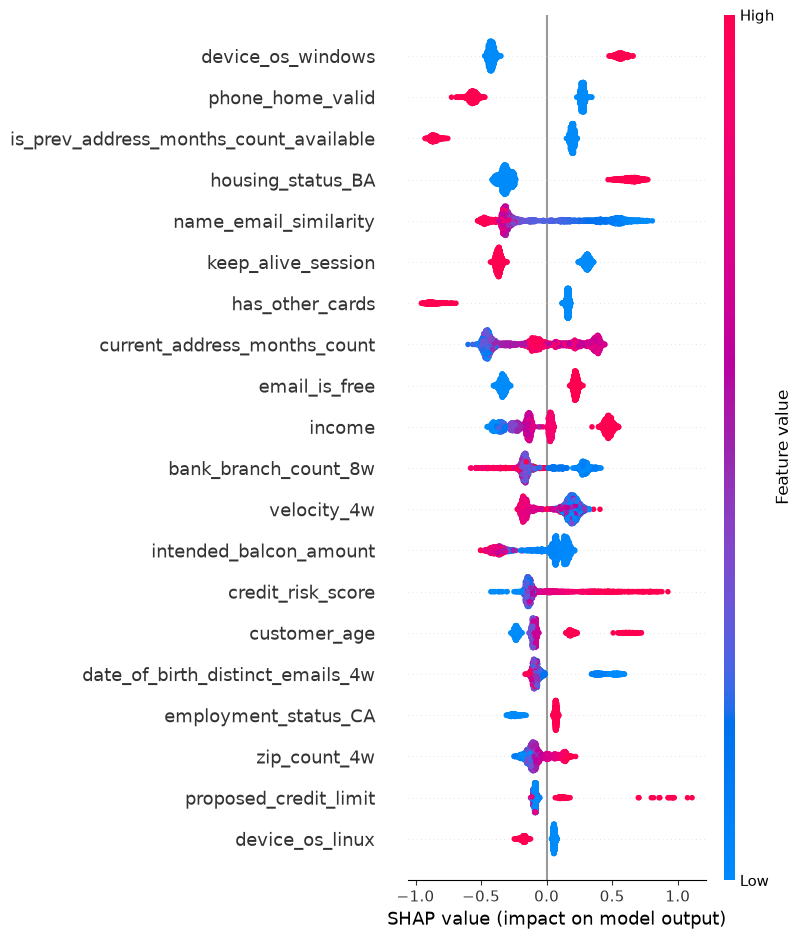

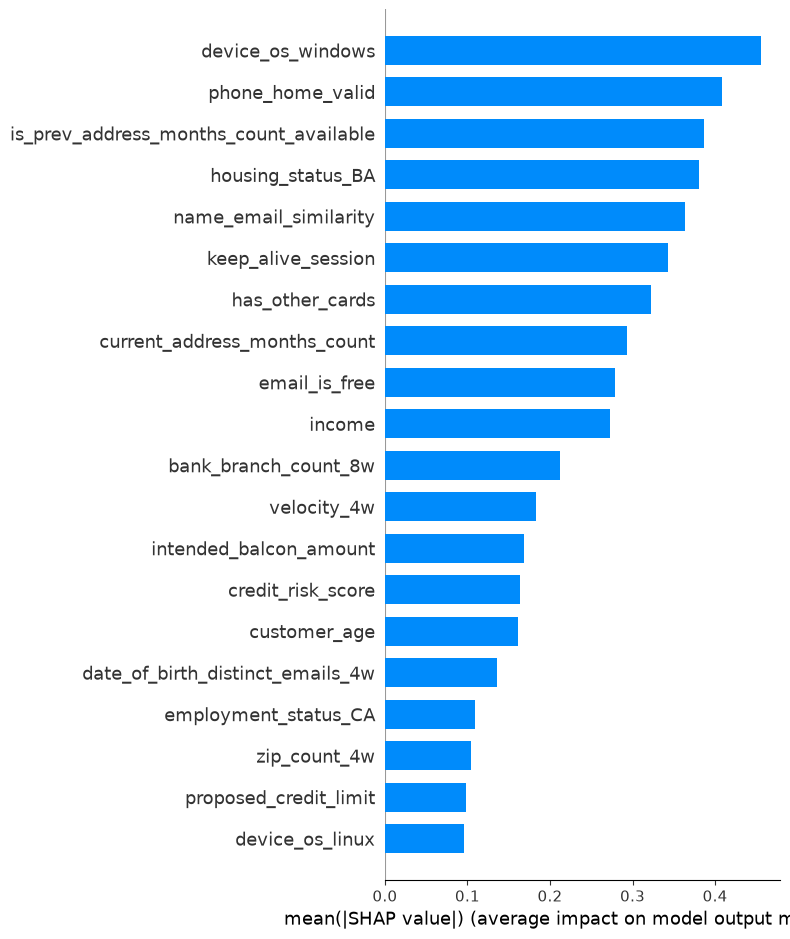

In [37]:
import shap
from catboost import CatBoostClassifier, Pool

X_samp = X_te.sample(min(2000, len(X_te)), random_state=42)

if isinstance(model, Pipeline):
    print("Best model is logistic regression — see coefficient importance above (SHAP skipped).")
elif isinstance(model, CatBoostClassifier):
    cats = [c for c in cat_cols if c in X_samp.columns]
    sv = model.get_feature_importance(Pool(X_samp, cat_features=cats), type="ShapValues")
    shap_values = sv[:, :-1]                      
    shap.summary_plot(shap_values, X_samp)
    shap.summary_plot(shap_values, X_samp, plot_type="bar")
else:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_samp)
    if isinstance(shap_values, list):            # some versions return [class0, class1]
        shap_values = shap_values[1]
    shap.summary_plot(shap_values, X_samp)
    shap.summary_plot(shap_values, X_samp, plot_type="bar")

## Error Analysis

Where does the winning model make mistakes, on the honest ~1.1%-prevalence test set? Confusion
matrix + score distribution, then errors broken down by `customer_age` group (fairness), by
`device_os`, and the worst false negatives / false positives for manual inspection.

model: catboost_under_tuned | threshold: 0.910

confusion matrix [rows=true 0/1, cols=pred 0/1]:
[[199255   2878]
 [  1978    900]]

               precision    recall  f1-score   support

           0      0.990     0.986     0.988    202133
           1      0.238     0.313     0.270      2878

    accuracy                          0.976    205011
   macro avg      0.614     0.649     0.629    205011
weighted avg      0.980     0.976     0.978    205011



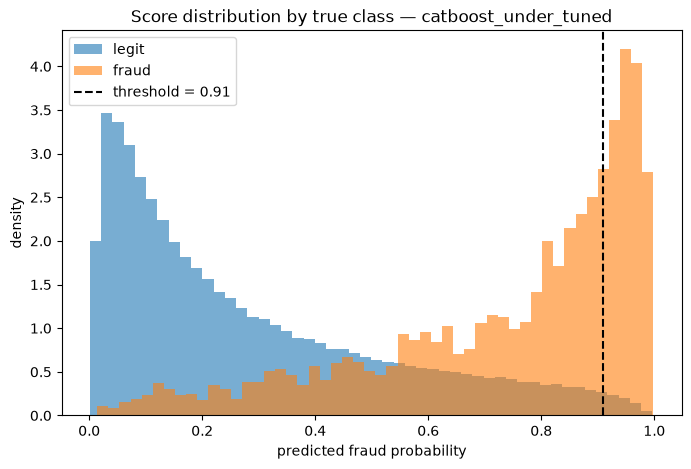

In [39]:
from sklearn.metrics import confusion_matrix, classification_report

thr = results[best_name]["threshold"]
score = model.predict_proba(X_te)[:, 1]

err = X_test.copy()                
err["y_true"] = y_test.values
err["score"] = score
err["y_pred"] = (err["score"] >= thr).astype(int)
err["error_type"] = np.select(
    [(err.y_true == 1) & (err.y_pred == 1),
     (err.y_true == 0) & (err.y_pred == 0),
     (err.y_true == 0) & (err.y_pred == 1)],
    ["TP", "TN", "FP"], default="FN")

print(f"model: {best_name} | threshold: {thr:.3f}\n")
print("confusion matrix [rows=true 0/1, cols=pred 0/1]:")
print(confusion_matrix(err.y_true, err.y_pred))
print("\n", classification_report(err.y_true, err.y_pred, digits=3))

plt.figure(figsize=(8, 5))
plt.hist(err.loc[err.y_true == 0, "score"], bins=50, density=True, alpha=.6, label="legit")
plt.hist(err.loc[err.y_true == 1, "score"], bins=50, density=True, alpha=.6, label="fraud")
plt.axvline(thr, color="k", ls="--", label=f"threshold = {thr:.2f}")
plt.xlabel("predicted fraud probability"); plt.ylabel("density")
plt.title(f"Score distribution by true class — {best_name}"); plt.legend(); plt.show()

In [38]:
err["age_group"] = np.where(err["customer_age"] >= 50, ">=50", "<50")

def rates(sub):
    tp = ((sub.y_true == 1) & (sub.y_pred == 1)).sum()
    fn = ((sub.y_true == 1) & (sub.y_pred == 0)).sum()
    fp = ((sub.y_true == 0) & (sub.y_pred == 1)).sum()
    tn = ((sub.y_true == 0) & (sub.y_pred == 0)).sum()
    return pd.Series({"n": len(sub), "frauds": int(tp + fn),
                      "recall_TPR": tp / (tp + fn) if (tp + fn) else np.nan,
                      "FPR": fp / (fp + tn) if (fp + tn) else np.nan})

age_tbl = err.groupby("age_group").apply(rates)
print("Errors by customer_age group:\n", age_tbl, "\n")
print(f"equal-opportunity  (TPR ratio): {age_tbl.recall_TPR.min() / age_tbl.recall_TPR.max():.3f}")
print(f"predictive-equality (FPR ratio): {age_tbl.FPR.min() / age_tbl.FPR.max():.3f}")


Errors by customer_age group:
                   n  frauds  recall_TPR       FPR
age_group                                        
<50        205011.0  2878.0    0.288742  0.012106 

equal-opportunity  (TPR ratio): 1.000
predictive-equality (FPR ratio): 1.000


In [40]:
cols = ["customer_age", "income", "credit_risk_score", "name_email_similarity",
        "proposed_credit_limit", "score"]

print("Top 10 FALSE NEGATIVES (actual fraud, lowest fraud score — most confident misses):")
display(err[err.error_type == "FN"].nsmallest(10, "score")[cols])

print("\nTop 10 FALSE POSITIVES (legit, highest fraud score):")
display(err[err.error_type == "FP"].nlargest(10, "score")[cols])

Top 10 FALSE NEGATIVES (actual fraud, lowest fraud score — most confident misses):


,customer_age,income,credit_risk_score,name_email_similarity,proposed_credit_limit,score
890236,0.523927,0.180468,-0.778889,-0.387827,-0.731975,0.014153
890596,-0.303090,0.523261,-0.342195,1.304683,-0.731975,0.022309
943791,-1.130107,-1.190706,-0.525325,0.447104,-0.731975,0.029930
904308,0.523927,1.208848,0.066325,0.058696,-0.731975,0.030731
843793,-0.303090,-0.505119,0.545279,-0.353597,-0.731975,0.033077
846657,0.523927,1.208848,-0.187239,-0.366907,-0.731975,0.033123
962445,1.350944,0.180468,-0.370369,1.026410,-0.731975,0.036273
981016,-0.303090,1.208848,-0.018197,-0.918069,-0.731975,0.037135
907111,-0.303090,0.866055,0.108586,0.777055,-0.731975,0.042903
875726,1.350944,0.180468,0.038151,1.332958,-0.731975,0.044477



Top 10 FALSE POSITIVES (legit, highest fraud score):


,customer_age,income,credit_risk_score,name_email_similarity,proposed_credit_limit,score
940079,0.523927,1.208848,2.362489,-1.432467,2.109506,0.996454
851342,2.177962,1.208848,2.235707,-0.545217,2.109506,0.994750
977593,-0.303090,1.208848,3.193615,-1.205638,1.754008,0.994744
804560,1.350944,1.208848,2.728748,-1.149289,1.754008,0.994388
876591,1.350944,1.208848,2.418836,-1.599711,2.109506,0.994070
843401,2.177962,1.208848,0.841104,-1.500633,1.754008,0.993480
867254,1.350944,1.208848,1.827187,-1.190295,2.109506,0.993058
904327,0.523927,1.208848,2.207533,0.970991,2.109506,0.992886
795223,0.523927,1.208848,2.348402,-1.273000,-0.731975,0.992466
804399,1.350944,1.208848,2.418836,-1.140674,2.109506,0.992146
